# Exponential Smoothing and Holt-Winters in R

## Overview

Exponential smoothing methods weight recent observations more heavily than older ones, with weights decaying exponentially. The `ets()` framework unifies all variants under a state-space Error-Trend-Seasonal model.

| Method | ETS code | Components | When to use |
|---|---|---|---|
| Simple exponential smoothing | ETS(A,N,N) | Level only | No trend, no seasonality |
| Holt's linear | ETS(A,A,N) | Level + trend | Trend, no seasonality |
| Holt-Winters additive | ETS(A,A,A) | Level + trend + additive seasonal | Constant seasonal amplitude |
| Holt-Winters multiplicative | ETS(A,A,M) | Level + trend + multiplicative seasonal | Seasonal amplitude grows with level |
| Damped Holt-Winters | ETS(A,Ad,A/M) | Damped trend | Trend flattens at longer horizons |

**ETS vs. ARIMA:** For short horizons, ETS often matches or beats ARIMA. ETS is faster and more interpretable (explicit level/trend/seasonal parameters). Always compare both on a test set before committing.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(forecast)
library(patchwork)

set.seed(42)
n <- 120
eco_monthly <- ts(
  60 + 0.12 * seq_len(n) +
  15 * sin(2 * pi * seq_len(n) / 12) +
  rnorm(n, 0, 5),
  start=c(2014,1), frequency=12
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'forecast' was built under R version 4.4.3"
Warning message:
"package 'patchwork' was built under R version

---

## Simple Exponential Smoothing — Effect of α

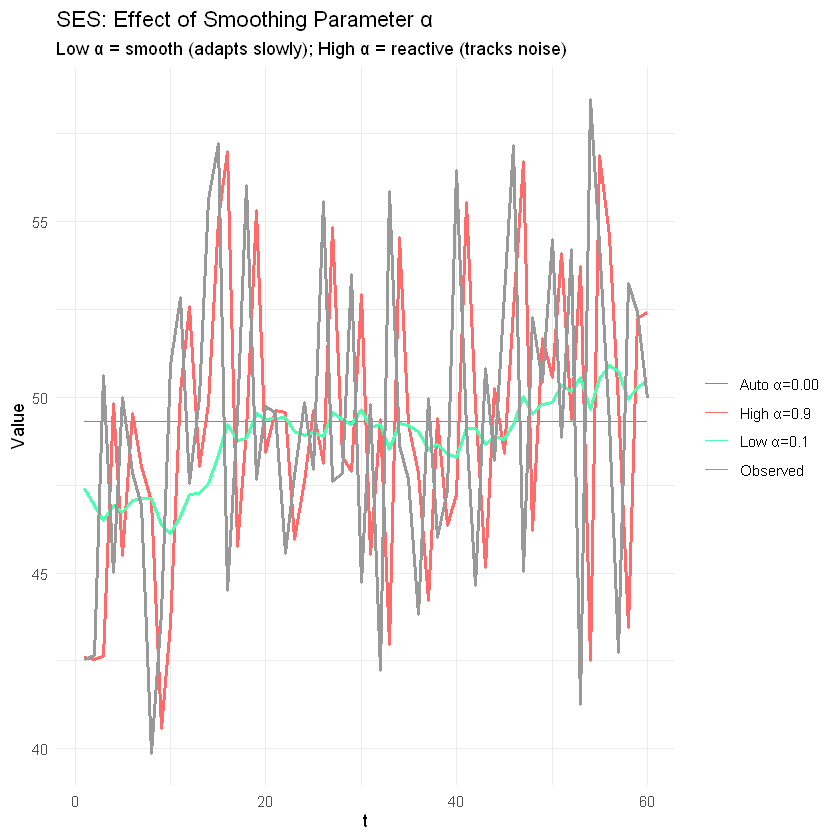

In [2]:
flat_ts <- ts(50 + rnorm(60, 0, 5), start=c(2014,1), frequency=1)

ses_auto <- forecast::ses(flat_ts, h=10)          # α from MLE
ses_low  <- forecast::ses(flat_ts, alpha=0.1, h=10)  # heavy smoothing
ses_high <- forecast::ses(flat_ts, alpha=0.9, h=10)  # reactive

tibble(
  t        = 1:60,
  observed = as.numeric(flat_ts),
  auto     = as.numeric(fitted(ses_auto)),
  low_a    = as.numeric(fitted(ses_low)),
  high_a   = as.numeric(fitted(ses_high))
) %>%
  pivot_longer(-t, names_to="series", values_to="value") %>%
  ggplot(aes(x=t, y=value, color=series, linewidth=series)) +
  geom_line() +
  scale_color_manual(
    values=c(observed="gray60", auto="#4a8fff", low_a="#4fffb0", high_a="#ff6b6b"),
    labels=c(sprintf("Auto α=%.2f", ses_auto$model$par["alpha"]),
             "High α=0.9", "Low α=0.1", "Observed")
  ) +
  scale_linewidth_manual(values=c(0.5,1,1,1), guide="none") +
  labs(title="SES: Effect of Smoothing Parameter α",
       subtitle="Low α = smooth (adapts slowly); High α = reactive (tracks noise)",
       x="t", y="Value", color=NULL) +
  theme_minimal()

---

## ETS Auto-Selection and Holt-Winters

In [3]:
# Auto ETS: selects best E/T/S combination by AICc
ets_auto <- forecast::ets(eco_monthly)
summary(ets_auto)
# Reports: selected model (e.g. ETS(A,A,A)), smoothing parameters,
# initial states, and AIC/AICc/BIC

# Manual Holt-Winters additive
hw_add  <- forecast::hw(eco_monthly, seasonal="additive",  h=24)
hw_mult <- forecast::hw(eco_monthly, seasonal="multiplicative", h=24)
hw_damp <- forecast::hw(eco_monthly, seasonal="additive", damped=TRUE, h=24)

# Compare on AICc
tibble(
  model = c("ETS auto", "HW additive", "HW multiplicative", "HW damped"),
  AICc  = c(ets_auto$aicc, hw_add$model$aicc,
             hw_mult$model$aicc, hw_damp$model$aicc)
) %>% mutate(delta_AICc=round(AICc-min(AICc),2)) %>% arrange(AICc) %>% print()

# Smoothing parameters of auto model
cat("\nSmoothing parameters:\n")
print(ets_auto$par[c("alpha","beta","gamma")])
# alpha: level smoothing (how quickly level adapts)
# beta:  trend smoothing (how quickly trend adapts)
# gamma: seasonal smoothing (how quickly seasonal pattern adapts)

ETS(A,N,A) 

Call:
forecast::ets(y = eco_monthly)

  Smoothing parameters:
    alpha = 0.1146 
    gamma = 1e-04 

  Initial states:
    l = 64.4132 
    s = 1.0718 -10.3277 -11.7244 -13.0404 -12.0747 -8.0865
           -0.1479 9.6924 13.3513 13.7354 11.8874 5.6633

  sigma:  5.4956

      AIC      AICc       BIC 
 998.5622 1003.1776 1040.3746 

Training set error measures:
                    ME     RMSE      MAE       MPE     MAPE      MASE
Training set 0.6210746 5.165128 4.208642 0.3001782 6.625527 0.6899786
                    ACF1
Training set -0.02542099

# A tibble: 4 × 3
  model              AICc delta_AICc
  <chr>             <dbl>      <dbl>
1 ETS auto          1003.       0   
2 HW damped         1006.       2.66
3 HW additive       1007.       3.42
4 HW multiplicative 1029.      26.1 

Smoothing parameters:
       alpha         <NA>        gamma 
0.1145546221           NA 0.0001281495 


---

## Forecasting and ETS vs. ARIMA Comparison

ETS test accuracy:
                 RMSE      MAE     MAPE      MASE
Training set 5.173319 4.271551 6.866811 0.6855288
Test set     5.328210 4.081259 5.623791 0.6549894

ARIMA test accuracy:
                 RMSE      MAE     MAPE      MASE
Training set 5.333546 3.950773 6.499272 0.6340481
Test set     5.057273 3.956046 5.816345 0.6348942


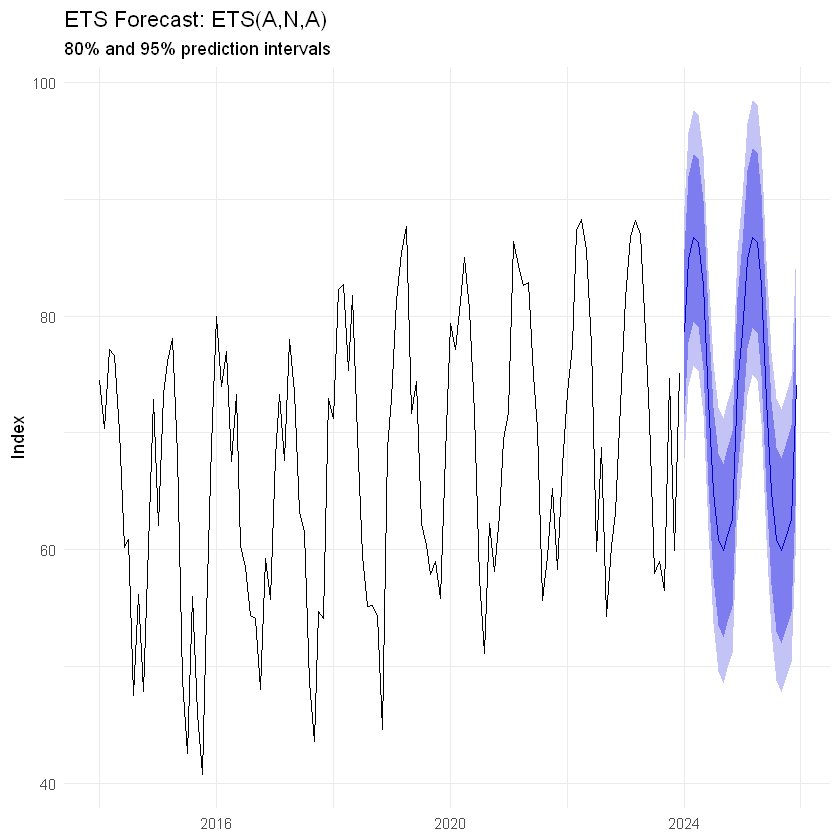

In [4]:
# Forecast with best ETS model
fc_ets <- forecast::forecast(ets_auto, h=24, level=c(80,95))

autoplot(fc_ets) +
  labs(title=paste("ETS Forecast:", ets_auto$method),
       subtitle="80% and 95% prediction intervals",
       x=NULL, y="Index") +
  theme_minimal()

# ── Test-set comparison: ETS vs. ARIMA ────────────────────────────────────────
train <- head(eco_monthly, 96)
test  <- tail(eco_monthly, 24)
h     <- 24

fc_ets_test   <- forecast::forecast(forecast::ets(train), h=h)
fc_arima_test <- forecast::forecast(
  forecast::auto.arima(train, seasonal=TRUE, stepwise=FALSE), h=h)

cat("ETS test accuracy:\n")
print(forecast::accuracy(fc_ets_test, test)[, c("RMSE","MAE","MAPE","MASE")])
cat("\nARIMA test accuracy:\n")
print(forecast::accuracy(fc_arima_test, test)[, c("RMSE","MAE","MAPE","MASE")])
# MASE < 1: better than seasonal naive forecast → acceptable baseline
# Choose the model with lower test RMSE and MASE

---

## Residual Diagnostics


	Ljung-Box test

data:  Residuals from ETS(A,N,A)
Q* = 18.176, df = 24, p-value = 0.7944

Model df: 0.   Total lags used: 24

Ljung-Box (lag 24): Q=18.176, p=0.0521


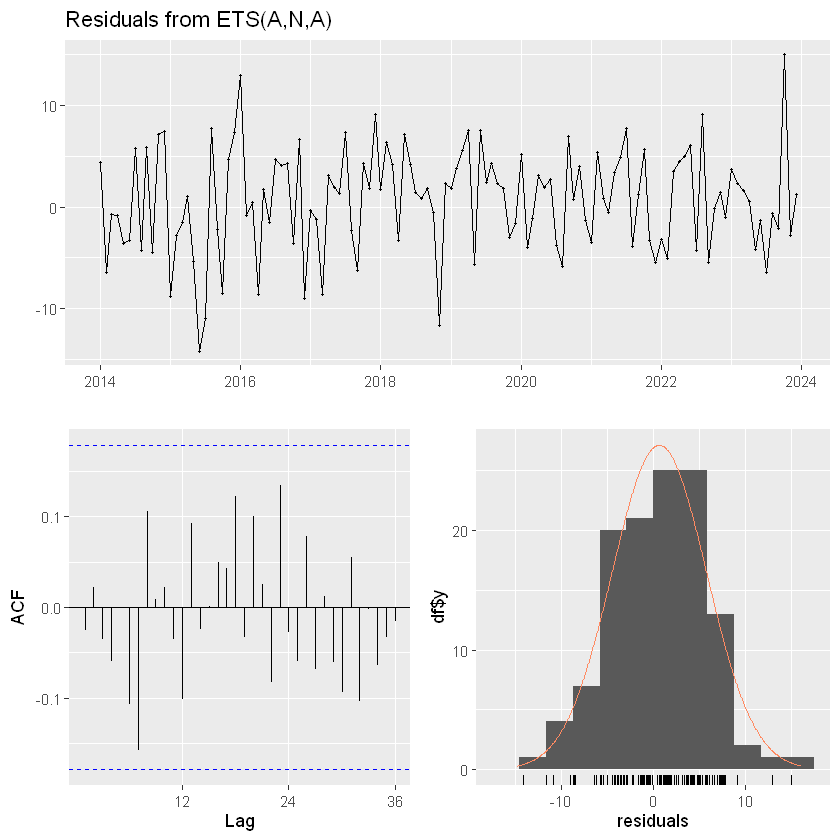

In [5]:
forecast::checkresiduals(ets_auto)

# Ljung-Box
n_par <- length(ets_auto$par)
lb <- Box.test(residuals(ets_auto), lag=24, type="Ljung-Box", fitdf=n_par)
cat(sprintf("Ljung-Box (lag 24): Q=%.3f, p=%.4f\n", lb$statistic, lb$p.value))

---

## Common Pitfalls

**1. Using multiplicative ETS on data with zeros or negatives**  
Multiplicative error/seasonal components require strictly positive data. If counts include zeros, use additive ETS or transform.

**2. Choosing ETS vs. ARIMA based on AICc alone**  
AICc values from ETS and ARIMA are not directly comparable because they use different likelihoods. Always compare on a held-out test set using RMSE or MASE.

**3. Not damping the trend for long horizons**  
Undamped Holt-Winters extrapolates the trend linearly forever. For horizons beyond a few seasonal periods, damped trend models (ETS(A,Ad,A)) typically outperform undamped versions — the trend rarely continues at the same rate indefinitely.

**4. Ignoring residual autocorrelation**  
ETS residuals should be white noise. Significant residual ACF spikes indicate the model has not captured all structure. Try a more complex ETS variant or switch to SARIMA.

**5. Not reporting the selected ETS model code**  
Always state the ETS(E,T,S) specification selected (e.g. ETS(A,A,A)), not just "Holt-Winters additive" — the error term specification (A vs. M) matters and affects the prediction intervals.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*